In [1]:
import os
import pandas as pd
import pm4py  # version 2.7.4
from pprint import pprint  # pretty printing
from pm4py.algo.discovery.alpha import algorithm as alpha_miner
from pm4py.algo.discovery.heuristics import algorithm as heuristics_miner
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.algo.evaluation import algorithm as evaluation
from pm4py.objects.conversion.log import converter as stream_converter
from pm4py.objects.log.importer.xes import importer as xes_import
from pm4py.visualization.petri_net import visualizer as pn_visualizer
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay
import pulp

In [2]:
# Load o CSV
df = pd.read_csv("caseid_meal/processed/event_log.csv")


# Verify first lines
display(df.head(5))

# Rename columns to pm4py format
df = df.rename(columns={
    "case_id": "case:concept:name",
    "event_type": "concept:name",
    "timestamp": "time:timestamp",
    "value": "glucose_value"  
})

# Converter columns to string
df["case:concept:name"] = df["case:concept:name"].astype(str)
df["concept:name"] = df["concept:name"].astype(str)

# Converter timestamp to datetime
df["time:timestamp"] = pd.to_datetime(df["time:timestamp"])

# Order per case and timestamp 
df = df.sort_values(["case:concept:name", "time:timestamp"])

# Convert to EventLog
event_log = pm4py.convert_to_event_log(df)


log_df = df.copy()

print("✅ Event log loaded successfully!")
print(f"Total traces (cases): {len(event_log)}")
print(f"Total events: {len(log_df)}")

,case_id,event_type,timestamp,value
0,2023-10-01,SleepTime,2023-10-01 20:51:00,33840.0
1,2023-10-01,SleepTime,2023-10-01 21:15:00,34140.0
2,2023-10-02,SleepTime,2023-10-02 20:13:00,36900.0
3,2023-10-02,SleepTime,2023-10-02 22:03:00,28080.0
4,2023-10-02,SleepTime,2023-10-02 22:03:00,27960.0


✅ Event log loaded successfully!
Total traces (cases): 4360
Total events: 30920


In [3]:
## --- Recall and Comprehensibility ---


def compute_recall(eval_result):
    precision = eval_result["precision"]
    fscore = eval_result["fscore"]

    # evitar divisões por zero
    if precision == 0 or (2 * precision - fscore) == 0:
        return 0.0

    recall = (fscore * precision) / (2 * precision - fscore)
    return recall

def compute_comprehensibility(net):
    num_places = len(net.places)
    num_transitions = len(net.transitions)

    total_elements = num_places + num_transitions

    if total_elements == 0:
        return 0.0

    # lower estruture, bigger score
    return 1 / total_elements



Alpha+ Miner applied successfully


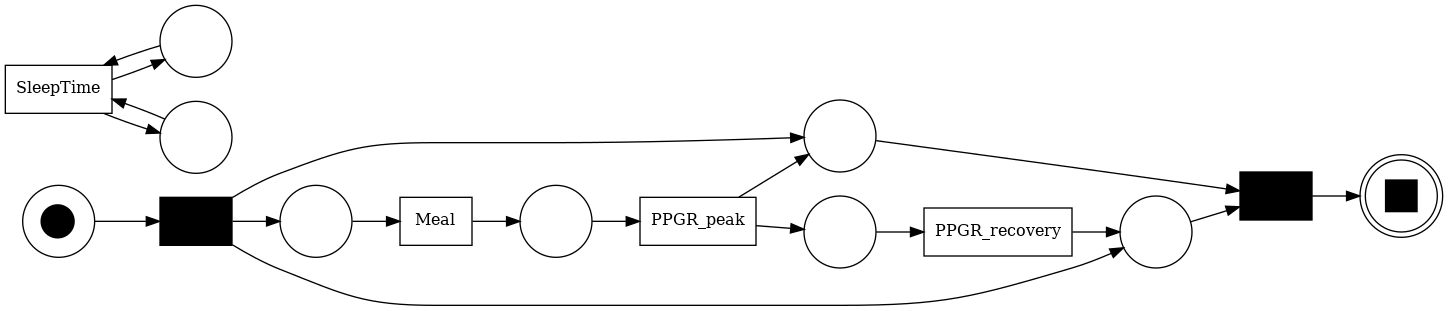

replaying log with TBR, completed traces ::   0%|          | 0/1435 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/3995 [00:00<?, ?it/s]


Evaluation - Alpha+ Miner:
{'comprehensibility': 0.06666666666666667,
 'fitness': {'average_trace_fitness': 0.8739558197198363,
             'log_fitness': 0.8736141293316229,
             'perc_fit_traces': 0.0,
             'percentage_of_fitting_traces': 0.0},
 'fscore': 0.8999646012032554,
 'generalization': 0.9818366810268226,
 'metricsAverageWeight': 0.8744226581640969,
 'precision': 0.9279541080122278,
 'recall': 0.873614129331623,
 'simplicity': 0.7142857142857143}


In [4]:
'''
    PM4Py – A Process Mining Library for Python
Copyright (C) 2024 Process Intelligence Solutions UG (haftungsbeschränkt)

This program is free software: you can redistribute it and/or modify
it under the terms of the GNU Affero General Public License as
published by the Free Software Foundation, either version 3 of the
License, or any later version.

This program is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the                                                               ##############
GNU Affero General Public License for more details.                                                                         # ALPHA PLUS #
                                                                                                                            ##############
You should have received a copy of the GNU Affero General Public License
along with this program.  If not, see this software project's root or
visit <https://www.gnu.org/licenses/>.

Website: https://processintelligence.solutions
Contact: info@processintelligence.solutions
'''
import time

from pm4py import util as pmutil
from pm4py.objects.log.obj import Trace
from pm4py.util import xes_constants as xes_util
from pm4py.objects.petri_net.utils.petri_utils import (
    add_arc_from_to,
    remove_place,
    remove_transition,
)
from pm4py.util import exec_utils
from enum import Enum
from copy import deepcopy
from typing import Optional, Dict, Any, Union, Tuple
from pm4py.objects.log.obj import EventLog
from pm4py.objects.petri_net.obj import PetriNet, Marking


class Parameters(Enum):
    ACTIVITY_KEY = pmutil.constants.PARAMETER_CONSTANT_ACTIVITY_KEY
    REMOVE_UNCONNECTED = "remove_unconnected"


def preprocessing(
    log: EventLog,
    parameters: Optional[Dict[Union[str, Parameters], Any]] = None,
) -> Any:
    """
    Preprocessing step for the Aplha+ algorithm. Removing all transitions from the log with a loop of length one.

    Parameters
    ------------
    log
        Event log
    parameters
        Parameters of the algorithm

    Returns
    -------------
    log
        filtered log and a list of the filtered transitions
    loop_one_list
        Loop one list
    A_filtered
        Dictionary: activity before the loop-length-one activity
    B_filtered
        Dictionary: activity after the loop-length-one activity
    loops_in_first_place
        Loops in source place
    loops_in_last_place
        Loops in sink place
    """
    loops_in_first_place = set()
    loops_in_last_place = set()

    if parameters is None:
        parameters = {}
    activity_key = exec_utils.get_param_value(
        Parameters.ACTIVITY_KEY, parameters, xes_util.DEFAULT_NAME_KEY
    )

    # List for values that have a loop of length one
    loop_one_list = []
    # Log without activities that have a loop of length one
    filtered_log = EventLog()
    # dictionary A: activity before the loop-length-one activity
    A = {}
    # dictionary B: activity after the loop-length-one activity
    B = {}
    A_filtered = {}
    B_filtered = {}
    # inserting artificial start and end activity, since it is not allowed to have a loop at the source place
    # (according to paper)
    for trace in log:
        trace.insert(0, {activity_key: "artificial_start"})
        trace.append({activity_key: "artificial_end"})
    for trace in log:
        i = 0
        while i < len(trace) - 1:
            test = trace[1]
            current = trace[i][activity_key]
            successor = trace[i + 1][activity_key]
            if current == successor:
                if current not in loop_one_list:
                    loop_one_list.append(current)
            i += 1
    for trace in log:
        i = 0
        filtered_trace = Trace()
        while i < len(trace) - 1:
            current = trace[i][activity_key]
            successor = trace[i + 1][activity_key]
            if current not in loop_one_list:
                filtered_trace.append(current)
            if successor in loop_one_list:
                if current not in loop_one_list:
                    if current in A:
                        A[successor].append(current)
                    else:
                        A[successor] = [current]
            if current in loop_one_list:
                if successor not in loop_one_list:
                    if current in B:
                        B[current].append(successor)
                    else:
                        B[current] = [successor]
            if i == len(trace) - 2:
                if successor not in loop_one_list:
                    filtered_trace.append(successor)
            i += 1
        filtered_log.append(filtered_trace)
    # Making sets instead of lists
    for key, value in A.items():
        A_filtered[key] = set(value)
    # Making sets instead of lists
    for key, value in B.items():
        B_filtered[key] = set(value)
    for trace in log:
        if trace.__getitem__(0) in loop_one_list:
            loops_in_first_place.add(trace.__getitem__(0))
        if trace.__getitem__(len(trace) - 1) in loop_one_list:
            loops_in_last_place.add(trace.__getitem__(len(trace) - 1))
    loops_in_first_place = list(loops_in_first_place)
    loops_in_last_place = list(loops_in_last_place)

    return (
        filtered_log,
        loop_one_list,
        A_filtered,
        B_filtered,
        loops_in_first_place,
        loops_in_last_place,
    )


def get_relations(log: EventLog):
    """
    Applying the classic Alpha Algorithm

    Parameters
    --------------
    log
        Filtered log

    Returns
    --------------
    causal
        Causal relations
    parallel
        Parallel relations
    follows
        Follows relations
    """
    # finding loops of length two
    # ordering relations
    triangle = {}
    for trace in log:
        i = 0
        while i < len(trace) - 2:
            current = trace.__getitem__(i)
            successor = trace.__getitem__(i + 1)
            successor2 = trace.__getitem__(i + 2)
            if current == successor2:
                if current in triangle:
                    triangle[current].append(successor)
                else:
                    triangle[current] = [successor]
            i += 1
    for key, value in triangle.items():
        triangle[key] = set(value)
    square = {}
    for key in triangle:
        for element in triangle[key]:
            if element in triangle:
                if key in triangle[element]:
                    if key in square and element in square:
                        square[key].append(element)
                        square[element].append(key)
                    elif key in square and element not in square:
                        square[key].append(element)
                        square[element] = [key]
                    elif key not in square and element in square:
                        square[key] = [element]
                        square[element].append(key)
                    else:
                        square[key] = [element]
                        square[element] = [key]
    for key, value in square.items():
        square[key] = set(value)
    # ordering relation following
    follows = {}
    for trace in log:
        i = 0
        while i < len(trace) - 1:
            current = trace.__getitem__(i)
            successor = trace.__getitem__(i + 1)
            if current in follows:
                if successor not in follows[current]:
                    follows[current].append(successor)
            else:
                follows[current] = [successor]
            i += 1
    # transforming list to set
    for key, value in follows.items():
        follows[key] = set(value)
    # ordering relation causal
    causal = {}
    if len(square) != 0:
        for key in follows:
            for element in follows[key]:
                if element in follows:
                    if key in square:
                        if (not (key in follows[element])) or (
                            element in square[key]
                        ):
                            if key in causal:
                                causal[key].append(element)
                            else:
                                causal[key] = [element]
                    else:
                        if not (key in follows[element]):
                            if key in causal:
                                causal[key].append(element)
                            else:
                                causal[key] = [element]
                else:
                    if key in causal:
                        causal[key].append(element)
                    else:
                        causal[key] = [element]
    else:
        for key in follows:
            for element in follows[key]:
                if element in follows:
                    if not (key in follows[element]):
                        if key in causal:
                            causal[key].append(element)
                        else:
                            causal[key] = [element]
                else:
                    if key in causal:
                        causal[key].append(element)
                    else:
                        causal[key] = [element]

    for key, value in causal.items():
        causal[key] = set(value)
    # ordering relation unrelated if no other ordering is applied
    # ordering relation parallel
    parallel = {}
    if len(square) != 0:
        for key in follows:
            for element in follows[key]:
                if element in follows:
                    if key in follows[element]:
                        if element in follows[key]:
                            if key in square:
                                if element not in square[key]:
                                    if key in parallel:
                                        parallel[key].append(element)
                                    else:
                                        parallel[key] = [element]
                            else:
                                if key in parallel:
                                    parallel[key].append(element)
                                else:
                                    parallel[key] = [element]

    else:
        for key in follows:
            for element in follows[key]:
                if element in follows:
                    if key in follows[element]:
                        if element in follows[key]:
                            if key in parallel:
                                parallel[key].append(element)
                            else:
                                parallel[key] = [element]

    for key, value in parallel.items():
        parallel[key] = set(value)
    return causal, parallel, follows


def processing(
    log: EventLog, causal: Tuple[str, str], follows: Tuple[str, str]
):
    """
    Applying the Alpha Miner with the new relations

    Parameters
    -------------
    log
        Filtered log
    causal
        Pairs that have a causal relation (->)
    follows
        Pairs that have a follow relation (>)

    Returns
    -------------
    net
        Petri net
    im
        Initial marking
    fm
        Final marking
    """
    # create list of all events
    labels = set()
    start_activities = set()
    end_activities = set()
    for trace in log:
        start_activities.add(trace.__getitem__(0))
        end_activities.add(trace.__getitem__(len(trace) - 1))
        for events in trace:
            labels.add(events)
    labels = list(labels)
    pairs = []

    for key, element in causal.items():
        for item in element:
            if get_sharp_relation(follows, key, key):
                if get_sharp_relation(follows, item, item):
                    pairs.append(({key}, {item}))

    # combining pairs
    for i in range(0, len(pairs)):
        t1 = pairs[i]
        for j in range(i, len(pairs)):
            t2 = pairs[j]
            if t1 != t2:
                if t1[0].issubset(t2[0]) or t1[1].issubset(t2[1]):
                    if get_sharp_relations_for_sets(
                        follows, t1[0], t2[0]
                    ) and get_sharp_relations_for_sets(follows, t1[1], t2[1]):
                        new_alpha_pair = (t1[0] | t2[0], t1[1] | t2[1])
                        if new_alpha_pair not in pairs:
                            pairs.append((t1[0] | t2[0], t1[1] | t2[1]))
    # maximize pairs
    cleaned_pairs = list(filter(lambda p: __pair_maximizer(pairs, p), pairs))
    # create transitions
    net = PetriNet("alpha_plus_net_" + str(time.time()))
    label_transition_dict = {}
    for label in labels:
        if label != "artificial_start" and label != "artificial_end":
            label_transition_dict[label] = PetriNet.Transition(label, label)
            net.transitions.add(label_transition_dict[label])
        else:
            label_transition_dict[label] = PetriNet.Transition(label, None)
            net.transitions.add(label_transition_dict[label])
    # and source and sink
    src = add_source(net, start_activities, label_transition_dict)
    sink = add_sink(net, end_activities, label_transition_dict)
    # create places
    for pair in cleaned_pairs:
        place = PetriNet.Place(str(pair))
        net.places.add(place)
        for in_arc in pair[0]:
            add_arc_from_to(label_transition_dict[in_arc], place, net)
        for out_arc in pair[1]:
            add_arc_from_to(place, label_transition_dict[out_arc], net)

    return net, Marking({src: 1}), Marking({sink: 1}), cleaned_pairs


def get_sharp_relation(follows, instance_one, instance_two):
    """
    Returns true if sharp relations holds

    Parameters
    -------------
    follows
        Follows relations
    instance_one
        Instance one
    instance_two
        Instance two

    Returns
    -------------
    bool
        Boolean (sharp relation holds?)
    """
    if instance_one in follows:
        if instance_two in follows:
            if (
                not instance_two in follows[instance_one]
                and not instance_one in follows[instance_two]
            ):
                return True
    if instance_one not in follows and instance_two not in follows:
        return True
    if instance_one in follows:
        if instance_two in follows[instance_one]:
            return False
    if instance_two in follows:
        if instance_one in follows[instance_two]:
            return False


def get_sharp_relations_for_sets(follows, set_1, set_2):
    """
    Returns sharp relations for sets

    Parameters
    ------------
    follows
        Follows relations
    set_1
        First set to consider
    set_2
        Second set to consider

    Returns
    ------------
    bool
        Boolean (sharp relation holds?)
    """
    for item_1 in set_1:
        for item_2 in set_2:
            if not get_sharp_relation(follows, item_1, item_2):
                return False
    return True


def postprocessing(
    net: PetriNet,
    initial_marking: Marking,
    final_marking: Marking,
    A,
    B,
    pairs,
    loop_one_list,
) -> Tuple[PetriNet, Marking, Marking]:
    """
    Adding the filtered transitions to the Petri net

    Parameters
    ------------
    loop_list
        List of looped activities
    classical_alpha_result
        Result after applying the classic alpha algorithm to the filtered log
    A
        See Paper for definition
    B
        See Paper for definition

    Returns
    ------------
    net
        Petri net
    im
        Initial marking
    fm
        Final marking
    """
    label_transition_dict = {}
    for label in loop_one_list:
        label_transition_dict[label] = PetriNet.Transition(label, label)
        net.transitions.add(label_transition_dict[label])

    # F L1L
    # Key is specific loop element
    for key, value in A.items():
        if key in B:
            A_without_B = value - B[key]
            B_without_A = B[key] - value
            pair = (A_without_B, B_without_A)
            for pair_try in pairs:
                in_part = pair_try[0]
                out_part = pair_try[1]
                if pair[0].issubset(in_part) and pair[1].issubset(out_part):
                    pair_try_place = PetriNet.Place(str(pair_try))
                    net.places.add(pair_try_place)
                    add_arc_from_to(
                        label_transition_dict[key], pair_try_place, net
                    )
                    add_arc_from_to(
                        pair_try_place, label_transition_dict[key], net
                    )
    return net, initial_marking, final_marking


def apply(
    trace_log: EventLog,
    parameters: Optional[Dict[Union[str, Parameters], Any]] = None,
) -> Tuple[PetriNet, Marking, Marking]:
    """
    Apply the Alpha Algorithm to a given log

    Parameters
    ------------
    trace_log
        Log
    parameters
        Possible parameters of the algorithm

    Returns
    ------------
    net
        Petri net
    im
        Initial marking
    fm
        Final marking
    """
    if parameters is None:
        parameters = {}

    # deep copy the log object because otherwise the original log would be modified with
    # artificial start/end activities
    trace_log = deepcopy(trace_log)

    remove_unconnected = exec_utils.get_param_value(
        Parameters.REMOVE_UNCONNECTED, parameters, False
    )

    (
        filtered_log,
        loop_one_list,
        A_filtered,
        B_filtered,
        loops_in_first,
        loops_in_last,
    ) = preprocessing(trace_log, parameters=parameters)
    causal, parallel, follows = get_relations(filtered_log)
    net, initial_marking, final_marking, pairs = processing(
        filtered_log, causal, follows
    )
    net, initial_marking, final_marking = postprocessing(
        net,
        initial_marking,
        final_marking,
        A_filtered,
        B_filtered,
        pairs,
        loop_one_list,
    )

    net, initial_marking = remove_initial_hidden_if_possible(
        net, initial_marking
    )
    net = remove_final_hidden_if_possible(net, final_marking)
    if remove_unconnected:
        net = remove_unconnected_transitions(net)

    return net, initial_marking, final_marking


def __pair_maximizer(alpha_pairs, pair):
    """
    Helping method, maximizing pairs
    """
    for alt in alpha_pairs:
        if (
            pair != alt
            and pair[0].issubset(alt[0])
            and pair[1].issubset(alt[1])
        ):
            return False
    return True


def add_source(net, start_activities, label_transition_dict):
    """
    Adding source pe
    """
    source = PetriNet.Place("start")
    net.places.add(source)
    for s in start_activities:
        add_arc_from_to(source, label_transition_dict[s], net)
    return source


def add_sink(net, end_activities, label_transition_dict):
    """
    Adding sink pe
    """
    end = PetriNet.Place("end")
    net.places.add(end)
    for e in end_activities:
        add_arc_from_to(label_transition_dict[e], end, net)
    return end


def remove_initial_hidden_if_possible(net: PetriNet, im: Marking):
    """
    Remove initial hidden transition if possible

    Parameters
    ------------
    net
        Petri net
    im
        Initial marking

    Returns
    ------------
    net
        Petri net
    im
        Possibly different initial marking
    """
    source = list(im.keys())[0]
    first_hidden = list(source.out_arcs)[0].target
    target_places_first_hidden = [x.target for x in first_hidden.out_arcs]
    if len(target_places_first_hidden) == 1:
        target_place_first_hidden = target_places_first_hidden[0]
        if len(target_place_first_hidden.in_arcs) == 1:
            new_im = Marking()
            new_im[target_place_first_hidden] = 1
            remove_place(net, source)
            remove_transition(net, first_hidden)
            return net, new_im
    return net, im


def remove_final_hidden_if_possible(net: PetriNet, fm: Marking):
    """
    Remove final hidden transition if possible

    Parameters
    -------------
    net
        Petri net
    fm
        Final marking

    Returns
    -------------
    net
        Petri net
    """
    sink = list(fm.keys())[0]
    last_hidden = list(sink.in_arcs)[0].source
    source_places_last_hidden = [x.source for x in last_hidden.in_arcs]
    removal_possible = len(source_places_last_hidden) == 1
    for place in source_places_last_hidden:
        if len(place.out_arcs) > 1:
            removal_possible = False
            break
        else:
            source_trans = set([x.source for x in place.in_arcs])
            for trans in source_trans:
                if len(trans.out_arcs) > 1:
                    removal_possible = False
                    break
    if removal_possible:
        all_sources = set()
        remove_transition(net, last_hidden)
        i = 0
        while i < len(source_places_last_hidden):
            place = source_places_last_hidden[i]
            source_trans = set([x.source for x in place.in_arcs])
            for trans in source_trans:
                if trans not in all_sources:
                    all_sources.add(trans)
                    add_arc_from_to(trans, sink, net)
            remove_place(net, place)
            i = i + 1
    return net


def remove_unconnected_transitions(net: PetriNet):
    """
    Remove unconnected transitions if any

    Parameters
    -------------
    net
        Petri net

    Returns
    -------------
    net
        Petri net without unconnected transitions
    """
    transitions = list(net.transitions)
    i = 0
    while i < len(transitions):
        if (
            len(transitions[i].in_arcs) == 0
            and len(transitions[i].out_arcs) == 0
        ):
            remove_transition(net, transitions[i])
        i = i + 1
    return net

# --- Alpha+ Miner ---
alphapl_net, alphapl_im, alphapl_fm = apply(
    event_log,
    parameters={
        "remove_unconnected": True  
    }
)

print("Alpha+ Miner applied successfully")

alphapl_gviz = pn_visualizer.apply(alphapl_net, alphapl_im, alphapl_fm)
pn_visualizer.view(alphapl_gviz)
pn_visualizer.save(alphapl_gviz, "caseid_day_HypoHyper/graphs/alpha+_petrinet.png")


# Avaliar Alpha+ Miner
eval_alphapl = evaluation.apply(event_log, alphapl_net, alphapl_im, alphapl_fm)
recall_alphapl = compute_recall(eval_alphapl)
eval_alphapl["recall"] = recall_alphapl
compreh_alphapl = compute_comprehensibility(alphapl_net)
eval_alphapl["comprehensibility"] = compreh_alphapl

print("\nEvaluation - Alpha+ Miner:")
pprint(eval_alphapl)



